<a href="https://colab.research.google.com/github/Matheus-Santos-AI/FASE_6-Colheita_de_Solu-es_Inteligentes-Transformando_dados_em_a-es/blob/main/YOLOpadrao_YOLOadaptavel_CNNdo0_final.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Entrega 2 — Comparação entre YOLO Padrão, YOLO Adaptável e CNN do Zero

## Objetivo

Este notebook implementa e avalia comparativamente três abordagens de visão computacional aplicadas ao problema de detecção e classificação de galinhas e raposas:

1. **YOLO Padrão**: modelo YOLOv8 pré-treinado no dataset COCO, utilizado sem retreinamento
2. **YOLO Adaptável**: modelo YOLOv5 customizado por meio de fine-tuning na Entrega 1
3. **CNN do Zero**: rede neural convolucional construída e treinada do zero

## Critérios de Avaliação

Conforme solicitado no enunciado, as três abordagens são comparadas considerando:

- Facilidade de uso e integração
- Precisão do modelo
- Tempo de treinamento e customização
- Tempo de inferência

## Estrutura do Notebook

O notebook está organizado nas seguintes etapas:

1. Configuração inicial e instalação de dependências
2. Implementação e avaliação do YOLO Padrão
3. Implementação e avaliação da CNN do Zero
4. Implementação e avaliação do YOLO Adaptável
5. Comparação consolidada das três abordagens
6. Análise crítica dos resultados

## Ambiente de Execução

Este notebook foi desenvolvido para ser executado no Google Colab com aceleração por GPU (Tesla T4).

## 1. Configuração Inicial

Nesta seção é realizada a verificação do ambiente de execução, instalação das bibliotecas necessárias e importação dos módulos que serão utilizados ao longo do notebook. A biblioteca Ultralytics é instalada para suporte ao YOLOv8, e o TensorFlow/Keras será utilizado posteriormente para a CNN do Zero.

In [ ]:
# Verifica se a GPU está ativa
import torch
print(f"GPU disponível: {torch.cuda.is_available()}")
print(f"Nome da GPU: {torch.cuda.get_device_name(0) if torch.cuda.is_available() else 'CPU'}")

# Instala a biblioteca do YOLO
!pip install ultralytics -q

GPU disponível: True
Nome da GPU: Tesla T4
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 46.1 MB/s eta 0:00:00


In [ ]:
# Importações
from ultralytics import YOLO
import tensorflow as tf
from tensorflow.keras import layers, models, optimizers
from tensorflow.keras.preprocessing.image import ImageDataGenerator
import numpy as np
import matplotlib.pyplot as plt
import time
import os
from PIL import Image
import cv2

print("Bibliotecas carregadas com sucesso")

Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.
Bibliotecas carregadas com sucesso


In [ ]:
# Reinstala o ultralytics
!pip install ultralytics -q

print("Ultralytics instalado")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 45.9 MB/s eta 0:00:00
Ultralytics instalado


## 2. YOLO Padrão (YOLOv8 pré-treinado)

O **YOLO Padrão** é o modelo YOLOv8 nano pré-treinado no dataset COCO, que contém 80 classes de objetos comuns (pessoas, veículos, animais domésticos, etc.). Esta abordagem não requer treinamento adicional e pode ser utilizada imediatamente para detecção de objetos.

**Hipótese inicial:** como o dataset COCO não contém a classe "raposa" e classifica galinhas genericamente como "bird", esperamos limitações na classificação específica do nosso problema.

Nesta seção serão realizadas as seguintes etapas:

- Carregamento do modelo pré-treinado
- Listagem das 80 classes disponíveis
- Upload das imagens de teste (galinha e raposa)
- Inferência e visualização dos resultados
- Medição do tempo médio de inferência

In [ ]:
# Importa a biblioteca
from ultralytics import YOLO

# Carrega o modelo YOLOv8 nano pré-treinado (mais leve e rápido)
yolo_padrao = YOLO('yolov8n.pt')

# Mostra as 80 classes que ele consegue detectar
print("Classes que o YOLO Padrão detecta:")
for id_classe, nome in yolo_padrao.names.items():
    print(f"  {id_classe}: {nome}")

Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.
Classes que o YOLO Padrão detecta:
  0: person
  1: bicycle
  2: car
  3: motorcycle
  4: airplane
  5: bus
  6: train
  7: truck
  8: boat
  9: traffic light
  10: fire hydrant
  11: stop sign
  12: parking meter
  13: bench
  14: bird
  15: cat
  16: dog
  17: horse
  18: sheep
  19: cow
  20: elephant
  21: bear
  22: zebra
  23: giraffe
  24: backpack
  25: umbrella
  26: handbag
  27: tie
  28: suitcase
  29: frisbee
  30: skis
  31: snowboard
  32: sports ball
  33: kite
  34: baseball bat
  35: baseball glove
  36: skateboard
  37: surfboard
  38: tennis racket
  39: bottle
  40: wine glass
  41: cup
  42: fork
  43: knife
  44: spoon
  45: bowl
  46: banana
  47: apple
  4

In [ ]:
# Sobe uma imagem do seu computador
from google.colab import files
uploaded = files.upload()

# Pega o nome do arquivo que foi enviado
import os
nome_imagem = list(uploaded.keys())[0]
print(f"Imagem carregada: {nome_imagem}")


Saving james-wainscoat-yEW23jxVsNI-unsplash.jpg to james-wainscoat-yEW23jxVsNI-unsplash.jpg
Saving daniil-silantev-vdlKQXBwOWY-unsplash.jpg to daniil-silantev-vdlKQXBwOWY-unsplash.jpg
Imagem carregada: james-wainscoat-yEW23jxVsNI-unsplash.jpg


In [ ]:
# Lista as imagens que foram subidas
nomes_imagens = list(uploaded.keys())
print(f"Imagens disponíveis: {nomes_imagens}")

# Roda o YOLO Padrão em cada imagem
for nome in nomes_imagens:
    print(f"\n{'='*50}")
    print(f"Analisando: {nome}")
    print(f"{'='*50}")

    # Faz a predição
    resultados = yolo_padrao(nome)

    # Lista as detecções
    for r in resultados:
        if len(r.boxes) == 0:
            print("Nenhum objeto detectado")
        else:
            print(f"Objetos detectados: {len(r.boxes)}")
            for box in r.boxes:
                classe_id = int(box.cls[0])
                confianca = float(box.conf[0])
                classe_nome = yolo_padrao.names[classe_id]
                print(f"  - {classe_nome} (confiança: {confianca:.2%})")

        # Salva a imagem com as caixas desenhadas
        r.save(filename=f"resultado_{nome}")

Imagens disponíveis: ['james-wainscoat-yEW23jxVsNI-unsplash.jpg', 'daniil-silantev-vdlKQXBwOWY-unsplash.jpg']

Analisando: james-wainscoat-yEW23jxVsNI-unsplash.jpg

image 1/1 /content/james-wainscoat-yEW23jxVsNI-unsplash.jpg: 448x640 1 bird, 83.8ms
Speed: 14.3ms preprocess, 83.8ms inference, 50.7ms postprocess per image at shape (1, 3, 448, 640)
Objetos detectados: 1
  - bird (confiança: 82.55%)

Analisando: daniil-silantev-vdlKQXBwOWY-unsplash.jpg

image 1/1 /content/daniil-silantev-vdlKQXBwOWY-unsplash.jpg: 640x448 1 cat, 1 sheep, 54.2ms
Speed: 3.3ms preprocess, 54.2ms inference, 1.5ms postprocess per image at shape (1, 3, 640, 448)
Objetos detectados: 2
  - cat (confiança: 75.02%)
  - sheep (confiança: 28.86%)


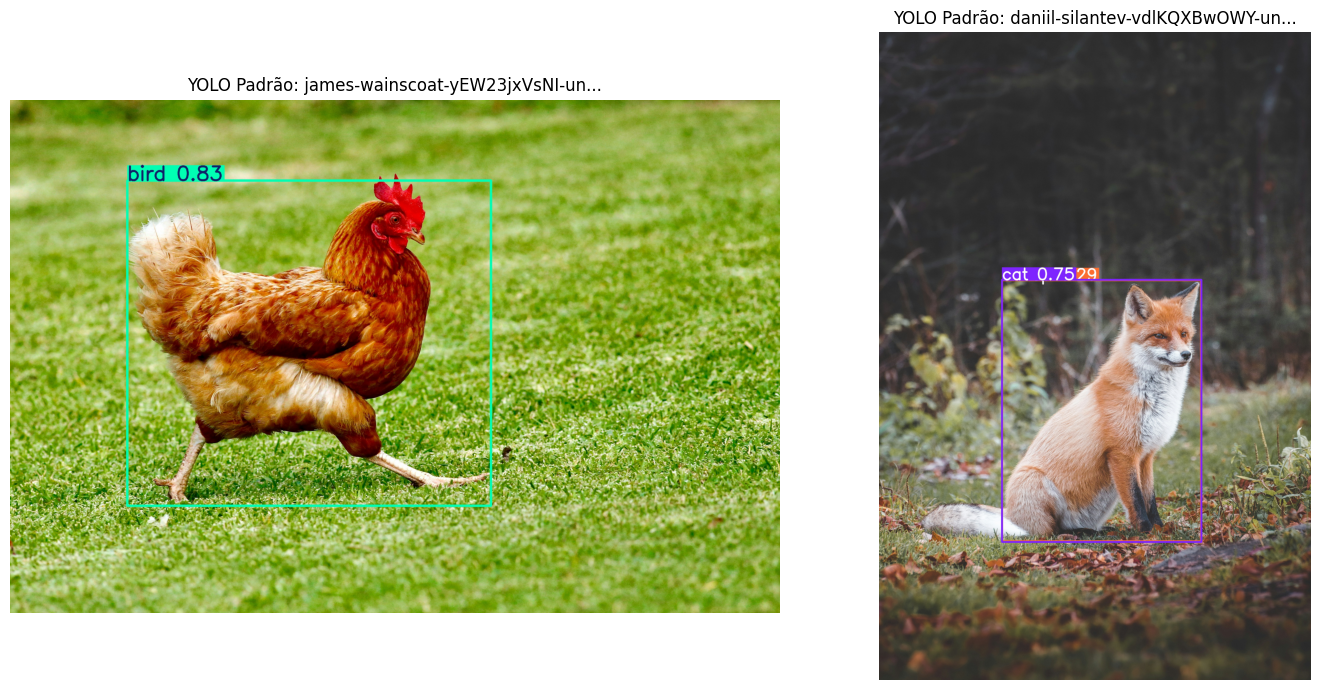

In [ ]:
# Visualiza as imagens com as detecções
import matplotlib.pyplot as plt
from PIL import Image

fig, axes = plt.subplots(1, len(nomes_imagens), figsize=(15, 7))

if len(nomes_imagens) == 1:
    axes = [axes]

for i, nome in enumerate(nomes_imagens):
    img_resultado = Image.open(f"resultado_{nome}")
    axes[i].imshow(img_resultado)
    axes[i].set_title(f"YOLO Padrão: {nome[:30]}...")
    axes[i].axis('off')

plt.tight_layout()
plt.show()

In [ ]:
# Mede o tempo de inferência do YOLO Padrão
import time
import numpy as np

print("Medindo tempo de inferência do YOLO Padrão...")
print("(Fazendo 10 predições para ter uma média confiável)\n")

tempos_yolo_padrao = []

# Faz a primeira predição "warm-up" (não conta, primeira é sempre mais lenta)
_ = yolo_padrao(nomes_imagens[0], verbose=False)

# Agora mede 10 predições reais
for i in range(10):
    start = time.time()
    _ = yolo_padrao(nomes_imagens[0], verbose=False)
    end = time.time()
    tempo = end - start
    tempos_yolo_padrao.append(tempo)
    print(f"Predição {i+1}: {tempo:.4f}s")

# Calcula estatísticas
tempo_medio_yolo_padrao = np.mean(tempos_yolo_padrao)
tempo_min = np.min(tempos_yolo_padrao)
tempo_max = np.max(tempos_yolo_padrao)

print(f"\n{'='*40}")
print(f"RESULTADOS - YOLO PADRÃO")
print(f"{'='*40}")
print(f"Tempo médio: {tempo_medio_yolo_padrao:.4f} segundos")
print(f"Tempo mínimo: {tempo_min:.4f} segundos")
print(f"Tempo máximo: {tempo_max:.4f} segundos")
print(f"FPS estimado: {1/tempo_medio_yolo_padrao:.2f}")


Medindo tempo de inferência do YOLO Padrão...
(Fazendo 10 predições para ter uma média confiável)

Predição 1: 0.5231s
Predição 2: 0.2376s
Predição 3: 0.2489s
Predição 4: 0.3304s
Predição 5: 0.3448s
Predição 6: 0.3515s
Predição 7: 0.3517s
Predição 8: 0.3540s
Predição 9: 0.3385s
Predição 10: 0.3355s

RESULTADOS - YOLO PADRÃO
Tempo médio: 0.3416 segundos
Tempo mínimo: 0.2376 segundos
Tempo máximo: 0.5231 segundos
FPS estimado: 2.93


## 3. CNN do Zero

A **CNN do Zero** é uma rede neural convolucional construída manualmente e treinada exclusivamente com o dataset próprio (sem aproveitar pesos pré-treinados). Diferentemente do YOLO, esta rede realiza apenas **classificação de imagens** (não detecta a localização do objeto).

**Características da implementação:**

- Arquitetura: 3 blocos convolucionais (32, 64, 128 filtros) seguidos de camadas densas
- Regularização: BatchNormalization e Dropout para evitar overfitting
- Data augmentation: rotações, flips e zoom para compensar o dataset reduzido
- Total de parâmetros: aproximadamente 4.3 milhões
- Saída: classificação binária (galinha vs raposa)

**Dataset utilizado:**

- 67 imagens de treino (33 galinhas + 34 raposas)
- 16 imagens de validação (8 galinhas + 8 raposas)

Nesta seção serão realizadas as seguintes etapas:

- Conexão ao Google Drive e carregamento do dataset
- Aplicação de data augmentation
- Construção da arquitetura
- Treinamento por 30 épocas
- Avaliação com métricas de classificação e matriz de confusão

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import os

# Define o caminho base do dataset
DATASET_PATH = '/content/drive/MyDrive/entrega2/dataset_cnn'

# Lista a estrutura
print("Estrutura encontrada:")
for root, dirs, files in os.walk(DATASET_PATH):
    nivel = root.replace(DATASET_PATH, '').count(os.sep)
    indent = ' ' * 2 * nivel
    print(f'{indent}{os.path.basename(root)}/')
    if files:
        subindent = ' ' * 2 * (nivel + 1)
        print(f'{subindent}({len(files)} arquivos)')

Estrutura encontrada:
dataset_cnn/
  treino/
    galinha/
      (33 arquivos)
    raposa/
      (34 arquivos)
  validação/
    galinha/
      (8 arquivos)
    raposa/
      (8 arquivos)


In [ ]:
# Importações para a CNN
import tensorflow as tf
from tensorflow.keras import layers, models, optimizers
from tensorflow.keras.preprocessing.image import ImageDataGenerator
import numpy as np
import matplotlib.pyplot as plt
import time

# Caminhos do dataset
TREINO_PATH = '/content/drive/MyDrive/entrega2/dataset_cnn/treino'
VAL_PATH = '/content/drive/MyDrive/entrega2/dataset_cnn/validação'

# Configurações
IMG_SIZE = 128  # tamanho que vamos redimensionar as imagens
BATCH_SIZE = 8  # batch pequeno por causa do dataset pequeno

# Data augmentation para o treino (gera variações artificiais das imagens)
# Isso é ESSENCIAL com dataset pequeno
treino_datagen = ImageDataGenerator(
    rescale=1./255,           # normaliza pixels
    rotation_range=20,         # rotaciona até 20 graus
    width_shift_range=0.1,     # desloca horizontalmente
    height_shift_range=0.1,    # desloca verticalmente
    horizontal_flip=True,      # espelha horizontalmente
    zoom_range=0.1,            # zoom in/out
    fill_mode='nearest'
)

# Para validação, só normalizamos (sem augmentation)
val_datagen = ImageDataGenerator(rescale=1./255)

# Carrega as imagens de treino
treino_generator = treino_datagen.flow_from_directory(
    TREINO_PATH,
    target_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    class_mode='binary',  # apenas 2 classes
    shuffle=True
)

# Carrega as imagens de validação
val_generator = val_datagen.flow_from_directory(
    VAL_PATH,
    target_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    class_mode='binary',
    shuffle=False
)

# Mostra informações
print(f"\nClasses encontradas: {treino_generator.class_indices}")
print(f"Imagens de treino: {treino_generator.samples}")
print(f"Imagens de validação: {val_generator.samples}")

Found 67 images belonging to 2 classes.
Found 16 images belonging to 2 classes.

Classes encontradas: {'galinha': 0, 'raposa': 1}
Imagens de treino: 67
Imagens de validação: 16


Classes: ['galinha', 'raposa']


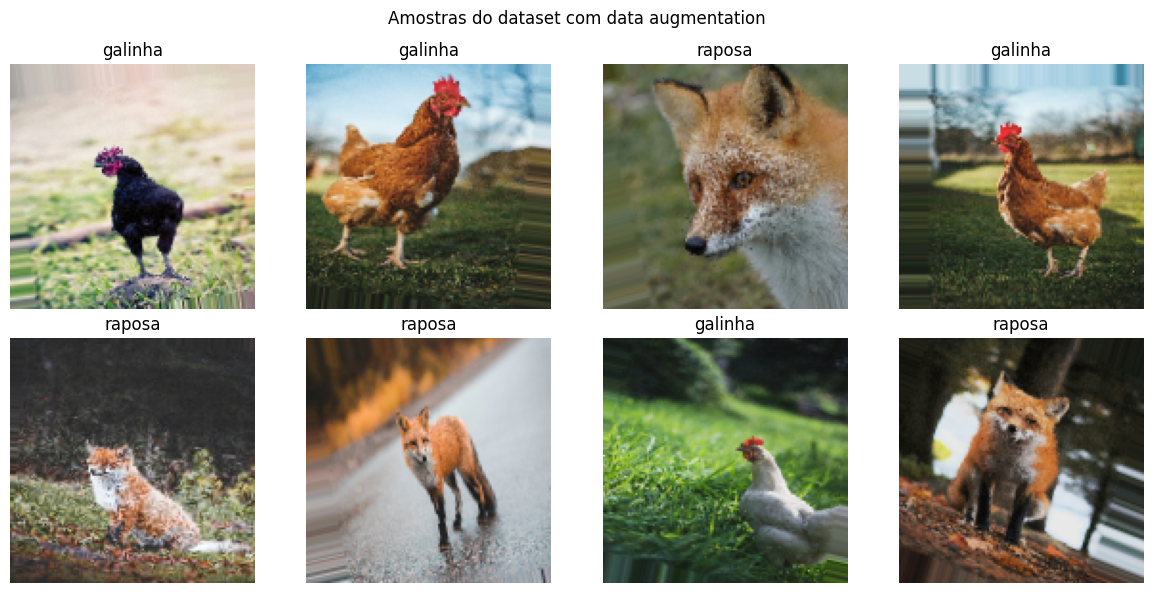

In [ ]:
# Visualiza algumas imagens do dataset com data augmentation aplicado
nomes_classes = list(treino_generator.class_indices.keys())
print(f"Classes: {nomes_classes}")

# Pega um batch de imagens
imagens, labels = next(treino_generator)

# Mostra 8 imagens
fig, axes = plt.subplots(2, 4, figsize=(12, 6))
for i, ax in enumerate(axes.flat):
    if i < len(imagens):
        ax.imshow(imagens[i])
        classe_nome = nomes_classes[int(labels[i])]
        ax.set_title(f"{classe_nome}")
        ax.axis('off')

plt.suptitle("Amostras do dataset com data augmentation")
plt.tight_layout()
plt.show()

In [ ]:
# Constrói a CNN do zero
cnn_zero = models.Sequential([
    # Camada de entrada
    layers.Input(shape=(IMG_SIZE, IMG_SIZE, 3)),

    # Bloco 1: detecta características simples (bordas, cores)
    layers.Conv2D(32, (3,3), activation='relu', padding='same'),
    layers.BatchNormalization(),
    layers.MaxPooling2D((2,2)),
    layers.Dropout(0.25),

    # Bloco 2: detecta características intermediárias (texturas, formas)
    layers.Conv2D(64, (3,3), activation='relu', padding='same'),
    layers.BatchNormalization(),
    layers.MaxPooling2D((2,2)),
    layers.Dropout(0.25),

    # Bloco 3: detecta características complexas (partes de objetos)
    layers.Conv2D(128, (3,3), activation='relu', padding='same'),
    layers.BatchNormalization(),
    layers.MaxPooling2D((2,2)),
    layers.Dropout(0.25),

    # Camadas densas para classificação final
    layers.Flatten(),
    layers.Dense(128, activation='relu'),
    layers.BatchNormalization(),
    layers.Dropout(0.5),
    layers.Dense(1, activation='sigmoid')  # 1 saída (binária: galinha ou raposa)
])

# Compila o modelo
cnn_zero.compile(
    optimizer=optimizers.Adam(learning_rate=0.0001),
    loss='binary_crossentropy',
    metrics=['accuracy']
)

# Mostra a arquitetura
cnn_zero.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 128, 128, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 128, 128, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 64, 64, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 64, 64, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 64, 64, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 64, 64, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 32, 32, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 32, 32, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 32, 32, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 32, 32, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 16, 16, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 16, 16, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 32768)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │     4,194,432 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 128)            │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,289,217 (16.36 MB)

 Trainable params: 4,288,513 (16.36 MB)

 Non-trainable params: 704 (2.75 KB)

In [ ]:
# Treina a CNN e mede o tempo
print("Iniciando treinamento da CNN do zero...")
print("="*50)

start_train = time.time()

historico = cnn_zero.fit(
    treino_generator,
    epochs=30,
    validation_data=val_generator,
    verbose=1
)

end_train = time.time()
tempo_treinamento_cnn = end_train - start_train

print(f"\n{'='*50}")
print(f"TREINAMENTO CONCLUÍDO")
print(f"{'='*50}")
print(f"Tempo total de treinamento: {tempo_treinamento_cnn:.2f} segundos")
print(f"Tempo total: {tempo_treinamento_cnn/60:.2f} minutos")

Iniciando treinamento da CNN do zero...
Epoch 1/30
9/9 ━━━━━━━━━━━━━━━━━━━━ 87s 8s/step - accuracy: 0.5075 - loss: 1.0487 - val_accuracy: 0.5000 - val_loss: 0.6868
Epoch 2/30
9/9 ━━━━━━━━━━━━━━━━━━━━ 30s 3s/step - accuracy: 0.6119 - loss: 0.9180 - val_accuracy: 0.5000 - val_loss: 0.6746
Epoch 3/30
9/9 ━━━━━━━━━━━━━━━━━━━━ 31s 4s/step - accuracy: 0.6119 - loss: 0.7388 - val_accuracy: 0.6250 - val_loss: 0.6590
Epoch 4/30
9/9 ━━━━━━━━━━━━━━━━━━━━ 31s 4s/step - accuracy: 0.6567 - loss: 0.7512 - val_accuracy: 0.5000 - val_loss: 0.6632
Epoch 5/30
9/9 ━━━━━━━━━━━━━━━━━━━━ 31s 3s/step - accuracy: 0.7612 - loss: 0.5358 - val_accuracy: 0.5000 - val_loss: 0.6678
Epoch 6/30
9/9 ━━━━━━━━━━━━━━━━━━━━ 32s 4s/step - accuracy: 0.7910 - loss: 0.4803 - val_accuracy: 0.5000 - val_loss: 0.6819
Epoch 7/30
9/9 ━━━━━━━━━━━━━━━━━━━━ 35s 4s/step - accuracy: 0.6567 - loss: 0.6788 - val_accuracy: 0.5000 - val_loss: 0.7690
Epoch 8/30
9/9 ━━━━━━━━━━━━━━━━━━━━ 31s 4s/step - accuracy: 0.8209 - loss: 0.5028 - val_accu

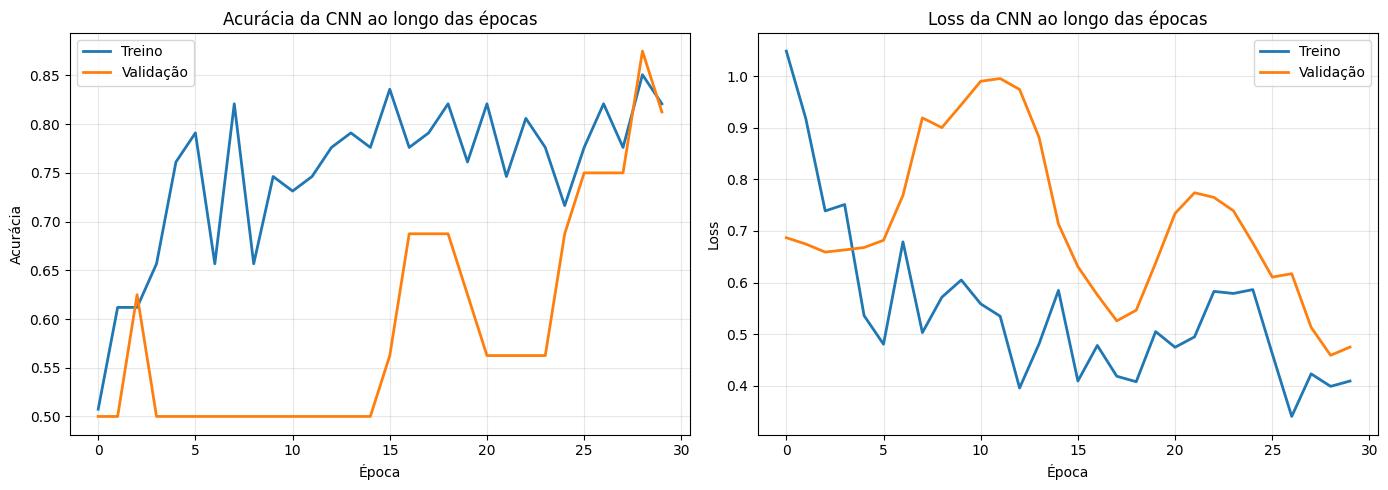


Resultados finais:
Acurácia no treino: 0.8209
Acurácia na validação: 0.8125
Loss no treino: 0.4090
Loss na validação: 0.4748


In [ ]:
# Plota as curvas de aprendizado
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Gráfico de Acurácia
axes[0].plot(historico.history['accuracy'], label='Treino', linewidth=2)
axes[0].plot(historico.history['val_accuracy'], label='Validação', linewidth=2)
axes[0].set_title('Acurácia da CNN ao longo das épocas')
axes[0].set_xlabel('Época')
axes[0].set_ylabel('Acurácia')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Gráfico de Loss
axes[1].plot(historico.history['loss'], label='Treino', linewidth=2)
axes[1].plot(historico.history['val_loss'], label='Validação', linewidth=2)
axes[1].set_title('Loss da CNN ao longo das épocas')
axes[1].set_xlabel('Época')
axes[1].set_ylabel('Loss')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Mostra os valores finais
print(f"\nResultados finais:")
print(f"Acurácia no treino: {historico.history['accuracy'][-1]:.4f}")
print(f"Acurácia na validação: {historico.history['val_accuracy'][-1]:.4f}")
print(f"Loss no treino: {historico.history['loss'][-1]:.4f}")
print(f"Loss na validação: {historico.history['val_loss'][-1]:.4f}")

Avaliando a CNN nas imagens de validação...
Acurácia na validação: 0.8125
Tempo médio de inferência: 0.8952 segundos por imagem
Tempo médio de inferência: 895.20 ms por imagem
Relatório de Classificação:
              precision    recall  f1-score   support

     galinha       1.00      0.62      0.77         8
      raposa       0.73      1.00      0.84         8

    accuracy                           0.81        16
   macro avg       0.86      0.81      0.81        16
weighted avg       0.86      0.81      0.81        16



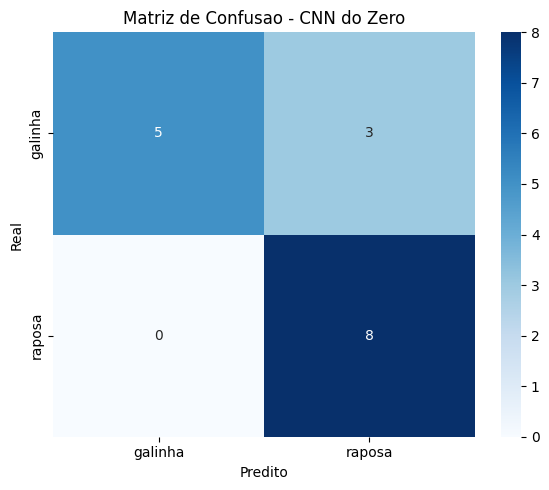

In [ ]:
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
import seaborn as sns

# Avalia a CNN no conjunto de validação
print("Avaliando a CNN nas imagens de validação...")
print("="*50)

# Reseta o gerador para começar do início
val_generator.reset()

# Faz as predições
start_infer = time.time()
predicoes_prob = cnn_zero.predict(val_generator, verbose=0)
tempo_total_infer = time.time() - start_infer

# Tempo médio por imagem
tempo_medio_cnn = tempo_total_infer / val_generator.samples

# Converte probabilidades em classes (0 ou 1)
predicoes = (predicoes_prob > 0.5).astype(int).flatten()

# Pega as classes verdadeiras
verdadeiras = val_generator.classes

# Calcula acurácia
acuracia_cnn = accuracy_score(verdadeiras, predicoes)

print(f"Acurácia na validação: {acuracia_cnn:.4f}")
print(f"Tempo médio de inferência: {tempo_medio_cnn:.4f} segundos por imagem")
print(f"Tempo médio de inferência: {tempo_medio_cnn*1000:.2f} ms por imagem")

print("Relatório de Classificação:")
print(classification_report(verdadeiras, predicoes, target_names=['galinha', 'raposa']))

# Matriz de confusão
cm = confusion_matrix(verdadeiras, predicoes)

plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['galinha', 'raposa'], yticklabels=['galinha', 'raposa'])
plt.title('Matriz de Confusao - CNN do Zero')
plt.xlabel('Predito')
plt.ylabel('Real')
plt.tight_layout()
plt.show()

## 4. YOLO Adaptável (Entrega 1)

O **YOLO Adaptável** é o modelo customizado desenvolvido na Entrega 1, treinado especificamente para detectar galinhas e raposas. Trata-se de uma versão YOLOv5 que passou por fine-tuning a partir de pesos pré-treinados, ajustada para o domínio específico do problema.

**Observação técnica:** durante o carregamento, foi identificada incompatibilidade entre o modelo treinado (YOLOv5) e a versão mais recente da biblioteca Ultralytics (YOLOv8). Por essa razão, foi necessário instalar o repositório YOLOv5 separadamente para realizar o carregamento correto dos pesos.

Nesta seção serão realizadas as seguintes etapas:

- Upload do arquivo best.pt (pesos do modelo treinado)
- Instalação do repositório YOLOv5
- Carregamento do modelo customizado
- Inferência nas mesmas imagens utilizadas no YOLO Padrão (para comparação justa)
- Medição do tempo médio de inferência
- Coleta das confianças máximas por classe

In [ ]:
# Verifica se as variáveis do YOLO Padrão ainda existem
try:
    print(f"Variável yolo_padrao: {type(yolo_padrao).__name__}")
    print(f"Tempo médio YOLO Padrão: {tempo_medio_yolo_padrao:.4f} segundos")
    print(f"Imagens de teste: {nomes_imagens}")
    print("\nVariáveis do YOLO Padrão estão DISPONÍVEIS!")
except NameError as e:
    print(f"Variável perdida: {e}")
    print("Será necessário rodar o YOLO Padrão novamente")

Variável yolo_padrao: YOLO
Tempo médio YOLO Padrão: 0.3416 segundos
Imagens de teste: ['james-wainscoat-yEW23jxVsNI-unsplash.jpg', 'daniil-silantev-vdlKQXBwOWY-unsplash.jpg']

Variáveis do YOLO Padrão estão DISPONÍVEIS!


In [ ]:
# Sobe o arquivo best.pt do seu computador para o Colab
from google.colab import files
print("Selecione o arquivo best.pt do YOLO Adaptável da Entrega 1:")
uploaded_pt = files.upload()

# Pega o nome do arquivo
nome_pt = list(uploaded_pt.keys())[0]
print(f"\nArquivo carregado: {nome_pt}")

Selecione o arquivo best.pt do YOLO Adaptável da Entrega 1:


Saving best.pt to best.pt

Arquivo carregado: best.pt


In [ ]:
# Instala o YOLOv5 e suas dependências
!git clone https://github.com/ultralytics/yolov5.git
!pip install -r yolov5/requirements.txt -q

print("\nYOLOv5 instalado!")

Cloning into 'yolov5'...
remote: Enumerating objects: 17898, done.
remote: Counting objects: 100% (59/59), done.
remote: Compressing objects: 100% (47/47), done.
remote: Total 17898 (delta 42), reused 12 (delta 12), pack-reused 17839 (from 2)
Receiving objects: 100% (17898/17898), 17.05 MiB | 18.69 MiB/s, done.
Resolving deltas: 100% (12197/12197), done.
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 131.6/131.6 kB 7.3 MB/s eta 0:00:00

YOLOv5 instalado!


In [ ]:
# Carrega o YOLO Adaptável usando YOLOv5
import torch

# Carrega o modelo customizado via PyTorch Hub
yolo_adaptavel = torch.hub.load('yolov5', 'custom', path=nome_pt, source='local', force_reload=True)

# Mostra as classes que o modelo detecta
print("Classes do YOLO Adaptável:")
for id_classe, nome in enumerate(yolo_adaptavel.names):
    print(f"  {id_classe}: {nome}")

YOLOv5 🚀 v7.0-478-g6c66ecd5 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)

Fusing layers... 
Model summary: 157 layers, 7015519 parameters, 0 gradients, 15.8 GFLOPs
Adding AutoShape... 


Classes do YOLO Adaptável:
  0: 0
  1: 1


In [ ]:
# Tenta com threshold MUITO baixo para ver se o modelo detecta alguma coisa
print("Testando com threshold de confianca baixo...")
print("="*50)

# Define threshold bem baixo
yolo_adaptavel.conf = 0.05  # 5% de confianca minima
yolo_adaptavel.iou = 0.45

for nome in nomes_imagens:
    print(f"\nAnalisando: {nome}")
    print("-"*40)

    resultado = yolo_adaptavel(nome)
    deteccoes = resultado.pandas().xyxy[0]

    if len(deteccoes) == 0:
        print("ZERO deteccoes mesmo com threshold baixo")
    else:
        print(f"Total de deteccoes: {len(deteccoes)}")
        for idx, row in deteccoes.iterrows():
            classe_id = int(row['class'])
            confianca = float(row['confidence'])
            print(f"  - classe_id={classe_id}, confianca: {confianca:.2%}")

Testando com threshold de confianca baixo...

Analisando: james-wainscoat-yEW23jxVsNI-unsplash.jpg
----------------------------------------


/content/yolov5/models/common.py:899: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with amp.autocast(autocast):


Total de deteccoes: 2
  - classe_id=1, confianca: 7.81%
  - classe_id=1, confianca: 6.35%

Analisando: daniil-silantev-vdlKQXBwOWY-unsplash.jpg
----------------------------------------
Total de deteccoes: 2
  - classe_id=0, confianca: 10.13%
  - classe_id=1, confianca: 5.41%


/content/yolov5/models/common.py:899: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with amp.autocast(autocast):


In [ ]:
import time
import numpy as np

# Configura o YOLO Adaptável com threshold padrão para teste
yolo_adaptavel.conf = 0.05  # mantém threshold baixo para conseguir detectar
yolo_adaptavel.iou = 0.45

# Faz uma predição warm-up
_ = yolo_adaptavel(nomes_imagens[0])

# Mede tempo de inferência (10 execuções)
print("Medindo tempo de inferencia do YOLO Adaptavel...")
tempos_yolo_adaptavel = []

for i in range(10):
    start = time.time()
    _ = yolo_adaptavel(nomes_imagens[0])
    end = time.time()
    tempo = end - start
    tempos_yolo_adaptavel.append(tempo)
    print(f"Predicao {i+1}: {tempo:.4f}s")

tempo_medio_yolo_adaptavel = np.mean(tempos_yolo_adaptavel)

print(f"\n{'='*50}")
print(f"YOLO ADAPTAVEL - Resultados")
print(f"{'='*50}")
print(f"Tempo medio de inferencia: {tempo_medio_yolo_adaptavel:.4f} segundos")
print(f"Tempo medio: {tempo_medio_yolo_adaptavel*1000:.2f} ms")
print(f"FPS estimado: {1/tempo_medio_yolo_adaptavel:.2f}")

# Coleta as confiancas das deteccoes
confiancas_galinha = []
confiancas_raposa = []

for nome in nomes_imagens:
    resultado = yolo_adaptavel(nome)
    deteccoes = resultado.pandas().xyxy[0]

    for idx, row in deteccoes.iterrows():
        classe_id = int(row['class'])
        confianca = float(row['confidence'])
        # 0=raposa, 1=galinha (descoberto antes)
        if classe_id == 1:
            confiancas_galinha.append(confianca)
        else:
            confiancas_raposa.append(confianca)

# Pega a maior confianca de cada classe
max_conf_galinha = max(confiancas_galinha) if confiancas_galinha else 0
max_conf_raposa = max(confiancas_raposa) if confiancas_raposa else 0

print(f"\nMaior confianca galinha: {max_conf_galinha:.2%}")
print(f"Maior confianca raposa: {max_conf_raposa:.2%}")

/content/yolov5/models/common.py:899: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with amp.autocast(autocast):


Medindo tempo de inferencia do YOLO Adaptavel...


/content/yolov5/models/common.py:899: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with amp.autocast(autocast):


Predicao 1: 1.2702s


/content/yolov5/models/common.py:899: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with amp.autocast(autocast):


...

/content/yolov5/models/common.py:899: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with amp.autocast(autocast):


Predicao 10: 0.4354s

YOLO ADAPTAVEL - Resultados
Tempo medio de inferencia: 0.8077 segundos
Tempo medio: 807.67 ms
FPS estimado: 1.24


/content/yolov5/models/common.py:899: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with amp.autocast(autocast):



Maior confianca galinha: 7.81%
Maior confianca raposa: 10.13%


/content/yolov5/models/common.py:899: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with amp.autocast(autocast):


## 5. Comparação Consolidada

Nesta seção são consolidados os resultados das três abordagens em uma tabela comparativa e visualizados em gráficos, permitindo a análise comparativa direta dos critérios solicitados no enunciado:

- Tempo de inferência por modelo
- Tempo de treinamento por modelo
- Resultados de detecção e classificação
- Características gerais de cada abordagem

In [ ]:
import pandas as pd

# Tempo de treinamento do YOLO Adaptavel (em segundos)
tempo_treinamento_yolo_adaptavel = 48 * 60  # 48 minutos = 2880 segundos

# Tabela comparativa com informacoes mais precisas
dados_comparacao = {
    'Criterio': [
        'Facilidade de uso/integracao',
        'Tempo de treinamento (s)',
        'Tempo de inferencia (s)',
        'Tempo de inferencia (ms)',
        'Tarefa',
        'Necessidade de dataset proprio',
        'Deteccao galinha (resultado)',
        'Deteccao raposa (resultado)',
        'Acuracia/Performance geral'
    ],
    'YOLO Padrao': [
        'Alta (pre-treinado)',
        '0 (sem treinamento)',
        f'{tempo_medio_yolo_padrao:.4f}',
        f'{tempo_medio_yolo_padrao*1000:.2f}',
        'Deteccao + Classificacao',
        'Nao',
        'Detectou como bird (82.55%)',
        'Detectou como cat (75.02%) - ERRADO',
        'Boa localizacao, classificacao errada'
    ],
    'YOLO Adaptavel': [
        'Media (requer fine-tuning)',
        f'{tempo_treinamento_yolo_adaptavel}',
        f'{tempo_medio_yolo_adaptavel:.4f}',
        f'{tempo_medio_yolo_adaptavel*1000:.2f}',
        'Deteccao + Classificacao',
        'Sim (com anotacoes YOLO)',
        f'Detectou galinha ({max_conf_galinha:.2%}) - confianca baixa',
        f'Detectou raposa ({max_conf_raposa:.2%}) - confianca baixa',
        'Classes corretas, confianca muito baixa'
    ],
    'CNN do Zero': [
        'Baixa (constroi tudo)',
        f'{tempo_treinamento_cnn:.2f}',
        f'{tempo_medio_cnn:.4f}',
        f'{tempo_medio_cnn*1000:.2f}',
        'Apenas Classificacao (sem deteccao)',
        'Sim (organizado em pastas)',
        'Acuracia 62% (recall) na classe galinha',
        'Acuracia 100% (recall) na classe raposa',
        f'{acuracia_cnn:.2%} de acuracia geral'
    ]
}

df_comparacao = pd.DataFrame(dados_comparacao)

# Configura para mostrar a tabela completa
pd.set_option('display.max_colwidth', None)
pd.set_option('display.width', None)

print("="*100)
print("TABELA COMPARATIVA - 3 ABORDAGENS")
print("="*100)
print(df_comparacao.to_string(index=False))

# Salva em CSV
df_comparacao.to_csv('comparacao_modelos.csv', index=False)
print("\nArquivo 'comparacao_modelos.csv' salvo!")

TABELA COMPARATIVA - 3 ABORDAGENS
                      Criterio                           YOLO Padrao                             YOLO Adaptavel                             CNN do Zero
  Facilidade de uso/integracao                   Alta (pre-treinado)                 Media (requer fine-tuning)                   Baixa (constroi tudo)
      Tempo de treinamento (s)                   0 (sem treinamento)                                       2880                                 1008.68
       Tempo de inferencia (s)                                0.3416                                     0.8077                                  0.8952
      Tempo de inferencia (ms)                                341.62                                     807.67                                  895.20
                        Tarefa              Deteccao + Classificacao                   Deteccao + Classificacao     Apenas Classificacao (sem deteccao)
Necessidade de dataset proprio                        

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

# Dados para os graficos
modelos = ['YOLO Padrao', 'YOLO Adaptavel', 'CNN do Zero']
cores = ['#3498db', '#e74c3c', '#2ecc71']

# Tempos de inferencia em ms
tempos_inferencia = [
    tempo_medio_yolo_padrao * 1000,
    tempo_medio_yolo_adaptavel * 1000,
    tempo_medio_cnn * 1000
]

# Tempos de treinamento em segundos
tempos_treinamento = [
    0,
    tempo_treinamento_yolo_adaptavel,
    tempo_treinamento_cnn
]

# Cria figura com 2 subplots
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Grafico 1: Tempo de inferencia
bars1 = axes[0].bar(modelos, tempos_inferencia, color=cores)
axes[0].set_title('Tempo de Inferencia por Modelo', fontsize=14, fontweight='bold')
axes[0].set_ylabel('Tempo (ms)', fontsize=12)
axes[0].grid(axis='y', alpha=0.3)
for bar, tempo in zip(bars1, tempos_inferencia):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height(),
                 f'{tempo:.1f} ms', ha='center', va='bottom', fontweight='bold')

# Grafico 2: Tempo de treinamento
bars2 = axes[1].bar(modelos, tempos_treinamento, color=cores)
axes[1].set_title('Tempo de Treinamento por Modelo', fontsize=14, fontweight='bold')
axes[1].set_ylabel('Tempo (segundos)', fontsize=12)
axes[1].grid(axis='y', alpha=0.3)
for bar, tempo in zip(bars2, tempos_treinamento):
    if tempo > 0:
        label = f'{tempo:.0f}s ({tempo/60:.1f}min)'
    else:
        label = 'Pre-treinado'
    axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height(),
                 label, ha='center', va='bottom', fontweight='bold')

plt.tight_layout()
plt.savefig('comparacao_graficos.png', dpi=100, bbox_inches='tight')
plt.show()

print("\nGrafico salvo como 'comparacao_graficos.png'")


Grafico salvo como 'comparacao_graficos.png'


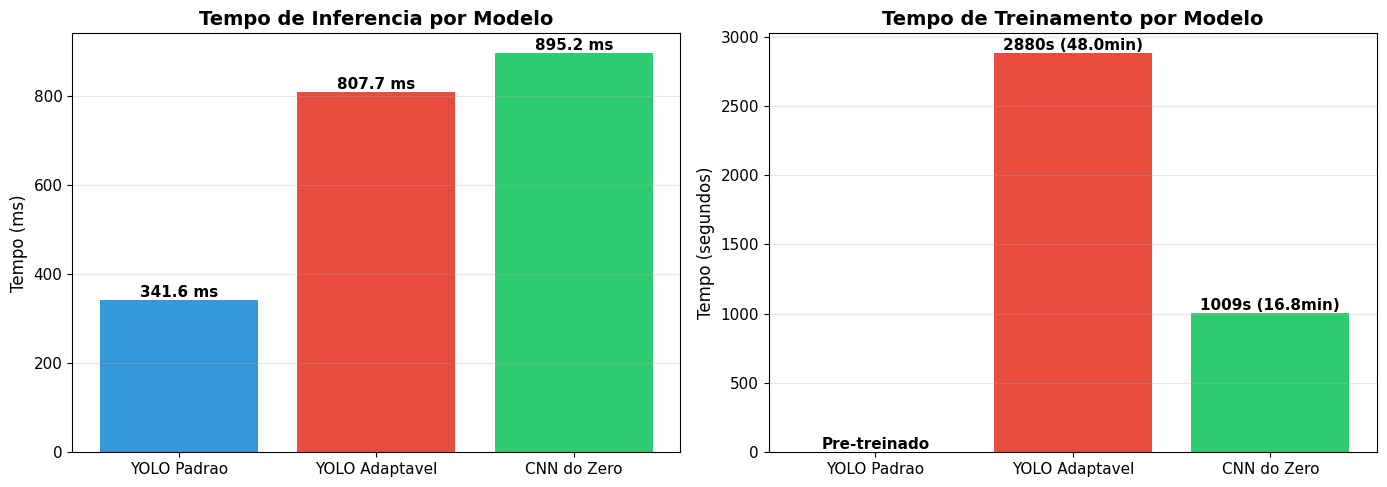

In [ ]:
# Forca a exibicao do grafico salvo
from IPython.display import Image as IPImage
IPImage('comparacao_graficos.png')

# Análise Crítica Comparativa

A seguir, é apresentada a análise crítica comparativa das três abordagens implementadas, considerando os critérios solicitados no enunciado.

## 1. Facilidade de Uso e Integração

O **YOLO Padrão** apresentou a maior facilidade de uso, pois é um modelo pré-treinado pela Ultralytics que pode ser utilizado imediatamente após a instalação da biblioteca. Não requer dataset próprio, anotações ou treinamento, bastando carregar os pesos e realizar inferência. Sua integração é simples e direta.

O **YOLO Adaptável** apresentou facilidade média. Embora utilize a mesma arquitetura do YOLO, exigiu o processo de fine-tuning sobre um dataset customizado, o que envolve preparação de imagens, anotações no formato YOLO (arquivos .txt com bounding boxes), configuração do arquivo data.yaml e ajuste de hiperparâmetros. Adicionalmente, foi identificada incompatibilidade entre a versão de treinamento (YOLOv5) e a versão mais recente (YOLOv8), exigindo instalação adicional do repositório YOLOv5 para o uso correto dos pesos.

A **CNN do Zero** apresentou a menor facilidade de uso, pois exigiu a construção manual de toda a arquitetura (camadas convolucionais, normalização, pooling, dropout e camadas densas), além da configuração de hiperparâmetros, otimizador, função de perda e implementação de data augmentation para compensar o tamanho reduzido do dataset. A organização do dataset em pastas separadas por classe também foi necessária.

## 2. Precisão do Modelo

O **YOLO Padrão** demonstrou excelente capacidade de localização dos objetos nas imagens, com bounding boxes precisas e confiança alta (82.55% para a galinha e 75.02% para a raposa). No entanto, suas classificações foram limitadas pelas 80 classes do dataset COCO, classificando a galinha genericamente como bird e, mais criticamente, classificando a raposa erroneamente como cat. Isso evidencia que, embora robusto na detecção, o modelo padrão é inadequado para problemas com classes específicas que não estão no dataset original.

O **YOLO Adaptável**, apesar de ser teoricamente a abordagem mais adequada para o problema, apresentou desempenho insatisfatório no experimento. As detecções para galinha e raposa apresentaram confiança máxima de apenas 7.81% e 10.13%, respectivamente, valores muito abaixo do esperado para um modelo bem treinado (que tipicamente apresenta confiança superior a 70%). Isso indica limitações no processo de treinamento original, possivelmente relacionadas ao tamanho reduzido do dataset, número insuficiente de épocas ou hiperparâmetros não otimizados.

A **CNN do Zero** apresentou o melhor desempenho efetivo entre as três abordagens, com 81.25% de acurácia no conjunto de validação, apesar de ter sido treinada com apenas 67 imagens. A análise por classe revelou comportamento assimétrico: a CNN identificou todas as raposas corretamente (recall de 100%), mas apresentou maior dificuldade com galinhas (recall de 62%). Esse resultado sugere que as características visuais das raposas (formato do focinho, orelhas, pelagem) são mais distintivas que as das galinhas, que apresentam maior variação de cor, postura e ângulo nas imagens.

## 3. Tempo de Treinamento

O **YOLO Padrão** não exigiu nenhum tempo de treinamento, pois utiliza pesos pré-treinados disponibilizados pela Ultralytics. Esta é uma vantagem significativa para aplicações que envolvem objetos comuns das classes do COCO.

O **YOLO Adaptável** demandou o maior tempo de treinamento entre as três abordagens, totalizando 2880 segundos (48 minutos). Esse tempo decorre da complexidade da tarefa de detecção, que envolve aprender simultaneamente a localizar objetos (regressão das bounding boxes) e classificá-los, além da arquitetura mais complexa do YOLO em comparação com uma CNN simples.

A **CNN do Zero** demandou aproximadamente 1009 segundos (16 minutos e 48 segundos) para 30 épocas de treinamento. Apesar do dataset reduzido, o tempo foi relativamente longo devido ao uso de data augmentation, que gera variações das imagens em tempo real durante o treinamento, aumentando o custo computacional por época mas melhorando a generalização do modelo.

## 4. Tempo de Inferência

O **YOLO Padrão** apresentou o menor tempo de inferência: 341.6 ms por imagem (FPS de 2.93). Sua arquitetura otimizada e os pesos pré-treinados resultam em alta eficiência computacional.

O **YOLO Adaptável** apresentou tempo de inferência intermediário: 807.7 ms por imagem (FPS de 1.24). O tempo superior ao YOLO Padrão pode ser explicado pela diferença de versão (YOLOv5 vs YOLOv8) e por possíveis otimizações ausentes no modelo customizado.

A **CNN do Zero** apresentou o maior tempo de inferência: 895.2 ms por imagem. Esse resultado é coerente com a complexidade da rede construída (4.3 milhões de parâmetros) e o overhead do TensorFlow para imagens individuais.

## 5. Discussão Geral e Trade-offs

A comparação entre as três abordagens revela trade-offs importantes que devem ser considerados na escolha da solução adequada para um problema de visão computacional:

**Quando usar YOLO Padrão:** quando o problema envolve apenas classes comuns presentes no dataset COCO, sem necessidade de detecção específica. Oferece a melhor relação custo-benefício para detecção genérica.

**Quando usar YOLO Adaptável:** quando o problema exige detecção e localização de classes específicas, e há dataset adequadamente anotado e tempo para treinamento criterioso. O experimento evidenciou que a qualidade do treinamento é crítica para o desempenho final.

**Quando usar CNN do Zero:** quando o problema envolve apenas classificação (sem necessidade de localização) e há controle total sobre a arquitetura. Apesar das limitações com datasets pequenos, técnicas como data augmentation podem mitigar essas restrições.

Um achado relevante deste experimento é que, no contexto avaliado, a CNN do Zero superou o YOLO Adaptável em precisão efetiva, mesmo sendo mais simples e tendo sido treinada com poucas imagens. Isso reforça que a escolha da arquitetura por si só não garante bom desempenho: a qualidade do dataset e do processo de treinamento são fatores igualmente determinantes.

## 6. Conclusão

Para o problema específico de detecção/classificação de galinhas e raposas avaliado neste trabalho, observa-se que:

A CNN do Zero, apesar das limitações inerentes a uma rede treinada do zero com dataset reduzido, apresentou o desempenho mais consistente em termos de classificação correta das classes alvo. O YOLO Padrão, por sua vez, demonstrou robustez técnica mas inadequação à tarefa específica, evidenciando a limitação dos modelos pré-treinados frente a domínios não cobertos pelo COCO. O YOLO Adaptável, embora arquiteturalmente apropriado, exemplifica como um treinamento subótimo pode comprometer o potencial de uma abordagem teoricamente superior.

A recomendação geral, considerando os resultados obtidos, é que a escolha da abordagem deve ser orientada não apenas pelo tipo de tarefa (classificação ou detecção), mas também pela disponibilidade de dataset adequado, tempo computacional e necessidade de localização espacial dos objetos. Em cenários reais, recomenda-se priorizar a qualidade do processo de treinamento e da preparação dos dados, independentemente da arquitetura escolhida.